# Univariate forecasting with `pymc_forecast`

This notebook ports the upstream NumPyro univariate forecasting example to the PyMC API.
The upstream notebook uses the NumPyro BART example dataset; this port uses the bundled
Victoria electricity demand series because `pymc_forecast` intentionally does not depend
on NumPyro's dataset mirror.

The model is the same baseline idea: a local level, Fourier seasonality, and Student-T
observation noise. All time handling uses labeled `xarray` coordinates.


## Prepare notebook


In [1]:
import io
import logging
from contextlib import contextmanager, redirect_stderr, redirect_stdout
from functools import partial

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm
import pytensor.tensor as pt
import xarray as xr

from pymc_forecast import (
    Forecaster,
    ForecastingModel,
    Horizon,
    backtest,
    build_model,
    eval_coverage,
    eval_crps,
    evaluate_forecast,
    fourier_features,
    predict,
    results_to_dataframe,
    time_series,
)
from pymc_forecast.data import FUTURE_DIM, TIME_DIM
from pymc_forecast.datasets import load_victoria_electricity

az.style.use("arviz-darkgrid")
plt.rcParams["figure.figsize"] = [10, 6]
plt.rcParams["figure.dpi"] = 100
plt.rcParams["figure.facecolor"] = "white"

logging.getLogger("pymc").setLevel(logging.ERROR)
logging.getLogger("pytensor").setLevel(logging.ERROR)

SEED = 42


## Read data

The bundled Victoria data contains eight weeks of hourly electricity demand. To keep the
example close to the upstream weekly ridership notebook, we aggregate it to daily average
demand and then standardize the series to keep weakly informative priors on a convenient
scale.


daily observations: 56


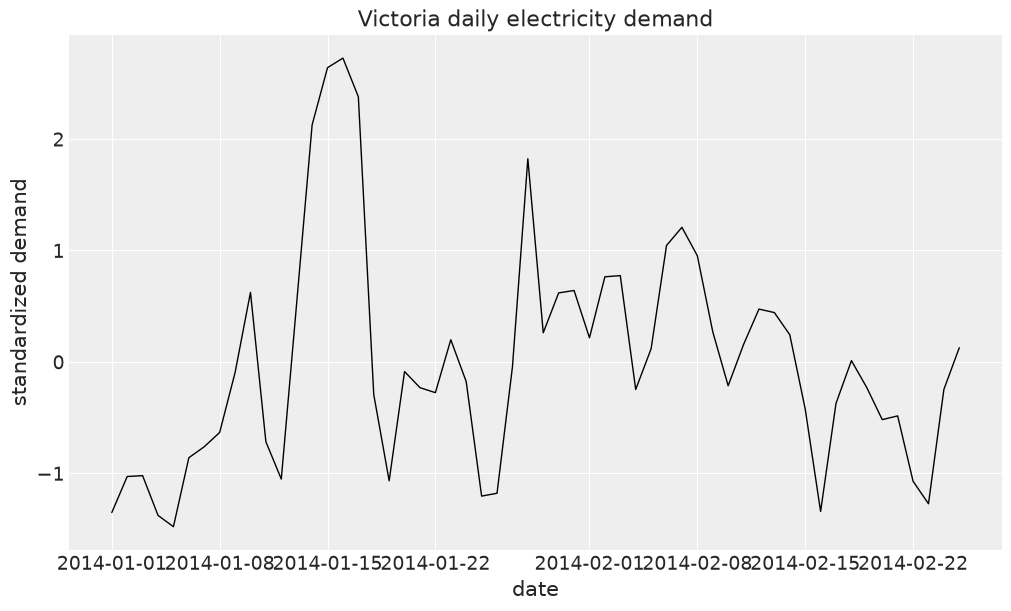

In [2]:
demand_hourly, temperature_hourly = load_victoria_electricity()
demand_daily = demand_hourly.resample({TIME_DIM: "D"}).mean()
y = ((demand_daily - demand_daily.mean()) / demand_daily.std()).rename("standardized_demand")
duration = y.sizes[TIME_DIM]
print("daily observations:", duration)

fig, ax = plt.subplots()
ax.plot(y[TIME_DIM].values, y.values, color="black", lw=1)
ax.set(title="Victoria daily electricity demand", xlabel="date", ylabel="standardized demand")
plt.show()


## Train-test split

Hold out the last two weeks as a test set. The training and test arrays keep their date
coordinates, and those coordinates will appear on posterior predictive draws.


train: 42 test: 14


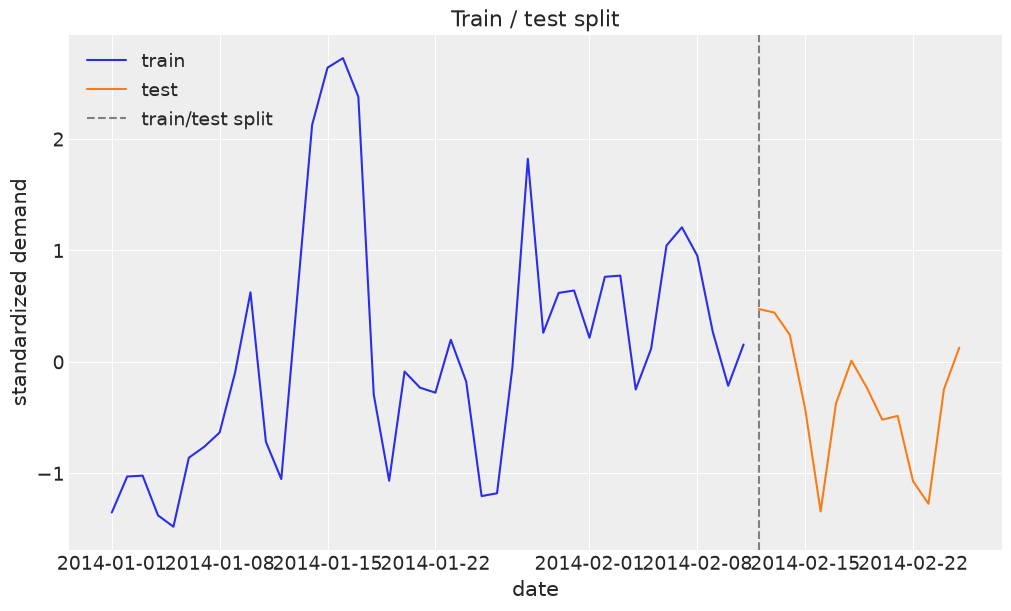

In [3]:
TEST_WINDOW = 14
T1 = duration - TEST_WINDOW

y_train = y.isel({TIME_DIM: slice(None, T1)})
y_test = y.isel({TIME_DIM: slice(T1, None)})
print("train:", y_train.sizes[TIME_DIM], "test:", y_test.sizes[TIME_DIM])

fig, ax = plt.subplots()
ax.plot(y_train[TIME_DIM].values, y_train.values, color="C0", label="train")
ax.plot(y_test[TIME_DIM].values, y_test.values, color="C1", label="test")
ax.axvline(y_test[TIME_DIM].values[0], color="gray", ls="--", label="train/test split")
ax.legend(loc="upper left")
ax.set(title="Train / test split", xlabel="date", ylabel="standardized demand")
plt.show()


## Seasonal features

Weekly Fourier features provide deterministic seasonal regressors. The phase is based on
integer day positions, while the `time` coordinate is the original daily datetime index.


covariates: Frozen({'time': 56, 'covariate': 6})


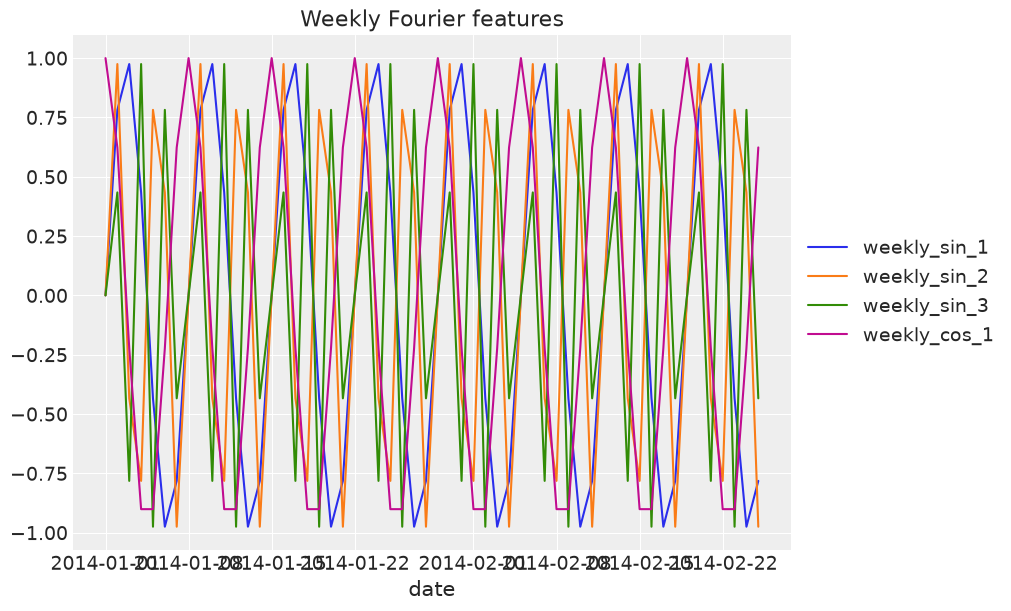

In [4]:
def make_fourier_covariates(index: np.ndarray) -> xr.DataArray:
    positions = np.arange(len(index), dtype=float)
    features = fourier_features(positions, period=7, num_terms=3)
    features = features.rename({"fourier": "covariate"})
    features = features.assign_coords({TIME_DIM: index})
    features = features.assign_coords(
        covariate=[f"weekly_{label}" for label in features["covariate"].values]
    )
    return features

covariates = make_fourier_covariates(y[TIME_DIM].values)
covariates_train = covariates.isel({TIME_DIM: slice(None, T1)})
print("covariates:", covariates.sizes)

fig, ax = plt.subplots()
for name in covariates["covariate"].values[:4]:
    ax.plot(covariates[TIME_DIM].values, covariates.sel(covariate=name).values, label=name)
ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))
ax.set(title="Weekly Fourier features", xlabel="date")
plt.show()


## Model specification

The mean has three pieces: a global intercept, a random-walk local level, and a linear
regression on Fourier features. The forecast horizon is represented by separate
`*_future` variables through `time_series`, so fitting and forecasting use one model body.


In [5]:
class LocalLevelSeasonal(ForecastingModel):
    """Local level + Fourier regression with Student-T observations."""

    def model(self, h: Horizon, covariates: xr.DataArray) -> None:
        bias = pm.Normal("bias", 0.0, 1.0)
        weight = pm.Normal("weight", 0.0, 0.3, dims="covariate")
        drift_scale = pm.HalfNormal("drift_scale", 0.02)
        sigma = pm.HalfNormal("sigma", 0.5)
        nu_minus_two = pm.Exponential("nu_minus_two", 1 / 10)
        nu = pm.Deterministic("nu", nu_minus_two + 2.0)

        drift = self.time_series(
            "drift",
            lambda name, dims: pm.Normal(name, 0.0, drift_scale, dims=dims),
        )
        level = pt.cumsum(drift)
        regression = pt.dot(covariates.values, weight)
        prediction = bias + level + regression

        self.predict(
            lambda name, mu, dims, observed: pm.StudentT(
                name,
                nu=nu,
                mu=mu,
                sigma=sigma,
                dims=dims,
                observed=observed,
            ),
            prediction,
        )


model = LocalLevelSeasonal()
train_model = build_model(model, y_train, covariates_train)
train_model


        bias ~ Normal(0, 1)
      weight ~ Normal(0, 0.3)
 drift_scale ~ HalfNormal(0, 0.02)
       sigma ~ HalfNormal(0, 0.5)
nu_minus_two ~ Exponential(<constant>)
       drift ~ Normal(0, drift_scale)
          nu = Deterministic(f(nu_minus_two))
         obs ~ StudentT(nu, f(drift, bias, weight), sigma)

## Plot helper


In [6]:
@contextmanager
def quiet_pymc():
    """Suppress sampler/progress chatter in executed notebook outputs."""
    with redirect_stdout(io.StringIO()), redirect_stderr(io.StringIO()):
        yield


def attach_constant_data(idata, *, name: str, values: np.ndarray, dim: str) -> None:
    """Add an ArviZ constant-data group used by plot_lm."""
    idata["constant_data"] = xr.Dataset(
        {name: (dim, np.asarray(values, dtype=float))},
        coords={dim: idata["observed_data"][dim].values},
    )


def lm_idata_from_forecast(
    samples: xr.DataArray,
    truth: xr.DataArray,
    *,
    x_name: str,
    x_values: np.ndarray,
):
    """Represent held-out forecasts as an ArviZ posterior predictive container."""
    return az.from_dict(
        {
            "posterior_predictive": {"obs": samples.values},
            "observed_data": {"obs": truth.values},
            "constant_data": {x_name: np.asarray(x_values, dtype=float)},
        },
        coords={TIME_DIM: truth[FUTURE_DIM].values},
        dims={"obs": [TIME_DIM], x_name: [TIME_DIM]},
    )


## Prior predictive checks


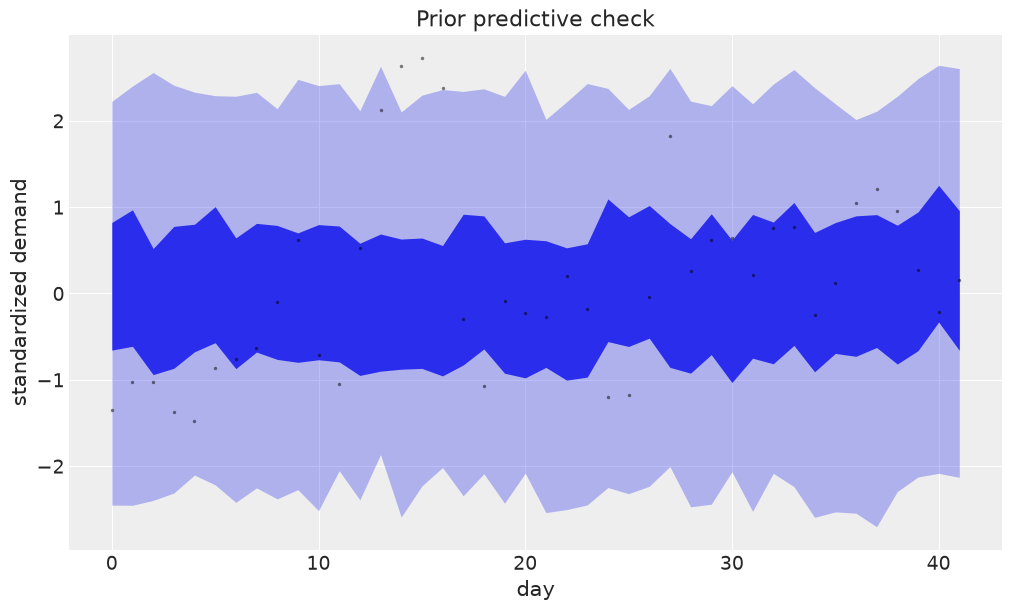

In [7]:
prior_model = build_model(model, y_train, covariates_train)
prior_idata = pm.sample_prior_predictive(
    draws=500,
    model=prior_model,
    var_names=["obs"],
    random_seed=SEED,
)
attach_constant_data(
    prior_idata,
    name="day",
    values=np.arange(y_train.sizes[TIME_DIM]),
    dim=TIME_DIM,
)

prior_pc = az.plot_lm(
    prior_idata,
    y="obs",
    x="day",
    group="prior_predictive",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={
        "ci_band": {"color": "C0"},
        "observed_scatter": {"color": "black", "s": 6, "alpha": 0.5},
        "pe_line": False,
    },
    figure_kwargs={"figsize": (10, 6)},
)
ax = prior_pc.viz["figure"].item().axes[0]
ax.set(title="Prior predictive check", xlabel="day", ylabel="standardized demand")
plt.show()


## Inference with ADVI

`Forecaster` fits the model with PyMC variational inference. The values below are chosen so
the notebook is interactive; increase `num_steps` and `num_samples` for a final analysis.


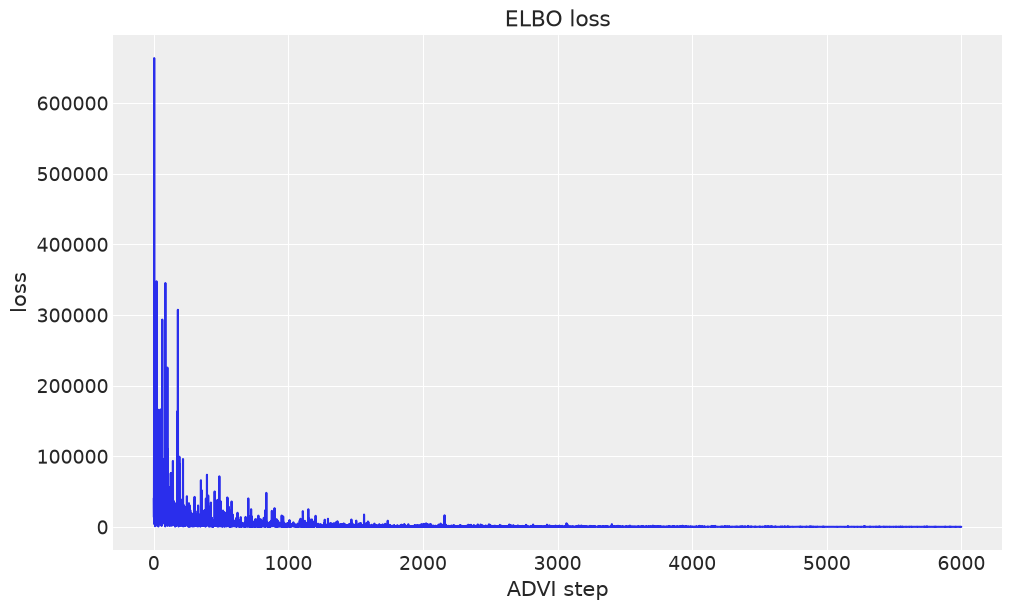

In [8]:
forecaster = Forecaster(
    model,
    y_train,
    covariates_train,
    optimizer=0.005,
    num_steps=6_000,
    random_seed=SEED,
    fit_kwargs={"progressbar": False},
)

fig, ax = plt.subplots()
ax.plot(forecaster.losses)
ax.set(title="ELBO loss", xlabel="ADVI step", ylabel="loss")
plt.show()


## Posterior predictive check and forecast


In [9]:
NUM_SAMPLES = 1_000

train_pp_idata = forecaster.predict_in_sample(
    num_samples=NUM_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
forecast_idata = forecaster.forecast(
    covariates,
    num_samples=NUM_SAMPLES,
    random_seed=SEED,
    progressbar=False,
)
attach_constant_data(
    train_pp_idata,
    name="day",
    values=np.arange(y_train.sizes[TIME_DIM]),
    dim=TIME_DIM,
)

train_pp = train_pp_idata["posterior_predictive"]["obs"]
forecast = forecast_idata["predictions"]["forecast"]
forecast_lm_idata = lm_idata_from_forecast(
    forecast,
    y_test.rename({TIME_DIM: FUTURE_DIM}),
    x_name="day",
    x_values=np.arange(T1, duration),
)

metrics = {
    "crps": eval_crps,
    "coverage_50": partial(eval_coverage, alpha=0.5),
    "coverage_90": partial(eval_coverage, alpha=0.9),
}
train_scores = evaluate_forecast(train_pp, y_train, metrics=metrics)
test_scores = evaluate_forecast(forecast, y_test.rename({TIME_DIM: FUTURE_DIM}), metrics=metrics)
print("train:", train_scores)
print("test: ", test_scores)


train: {'crps': 0.5836467045142693, 'coverage_50': 0.8095238095238095, 'coverage_90': 1.0}
test:  {'crps': 0.5832343251310742, 'coverage_50': 1.0, 'coverage_90': 1.0}


## Forecast visualization


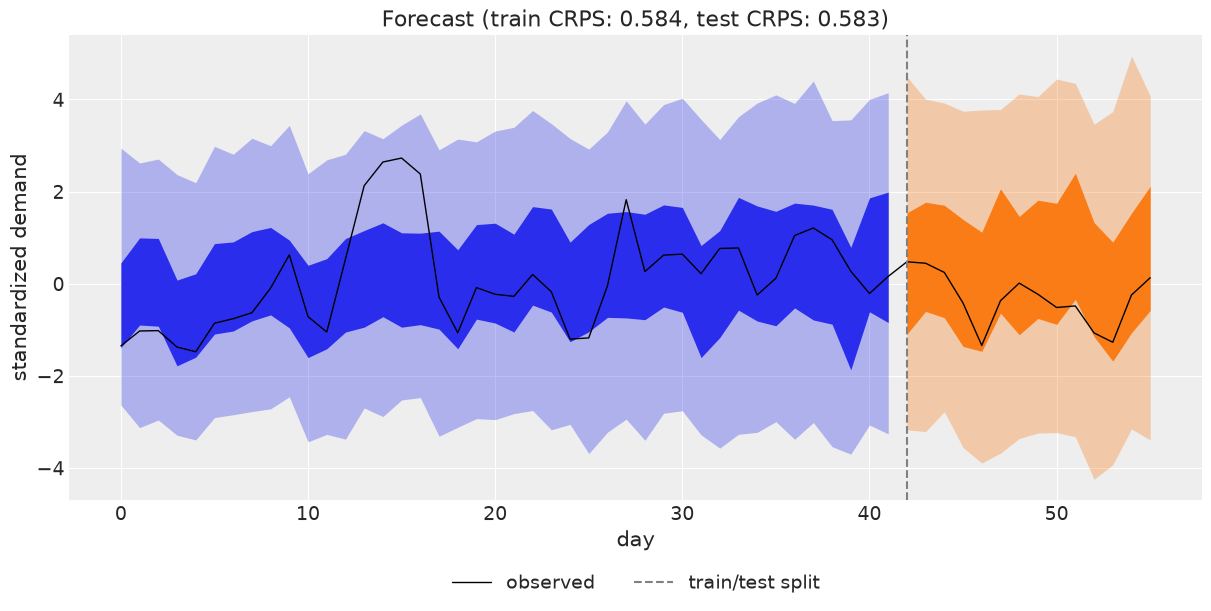

In [10]:
forecast_title = (
    f"Forecast (train CRPS: {train_scores['crps']:.3f}, "
    f"test CRPS: {test_scores['crps']:.3f})"
)

pc = az.plot_lm(
    train_pp_idata,
    y="obs",
    x="day",
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C0"}, "observed_scatter": False, "pe_line": False},
    figure_kwargs={"figsize": (12, 6)},
)
az.plot_lm(
    forecast_lm_idata,
    y="obs",
    x="day",
    plot_collection=pc,
    ci_kind="hdi",
    ci_prob=(0.5, 0.94),
    smooth=False,
    visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
)
ax = pc.viz["figure"].item().axes[0]
ax.plot(np.arange(duration), y.values, color="black", lw=1, label="observed")
ax.axvline(T1, color="gray", ls="--", label="train/test split")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
ax.set(title=forecast_title, xlabel="day", ylabel="standardized demand")
plt.show()


## Rolling-origin backtesting

The upstream NumPyro notebook also shows a vectorized rolling backtest. This PyMC port does
not implement the JAX `vmap` equivalent; the supported API is the loop-based `backtest`,
which keeps each fold's forecasts labeled by their real time coordinates.


In [11]:
backtest_model = LocalLevelSeasonal()
results = backtest(
    y,
    covariates,
    backtest_model,
    metrics=metrics,
    test_window=7,
    stride=7,
    min_train_window=28,
    num_samples=300,
    eval_train=True,
    keep_predictions=True,
    forecaster_options={"optimizer": 0.005, "num_steps": 3_000},
    random_seed=SEED,
)
summary = results_to_dataframe(results)
summary


,t0,t1,t2,num_samples,train_walltime,test_walltime,crps,coverage_50,coverage_90,train_crps,train_coverage_50,train_coverage_90
0,0,28,35,300,13.130454,1.866788,0.600627,1.0,1.0,0.664243,0.785714,1.0
1,0,35,42,300,9.014773,2.300097,0.609601,1.0,1.0,0.669143,0.828571,1.0
2,0,42,49,300,2.666272,1.457180,0.646506,1.0,1.0,0.678381,0.833333,1.0
3,0,49,56,300,10.620816,2.230554,0.737415,1.0,1.0,0.663678,0.877551,1.0


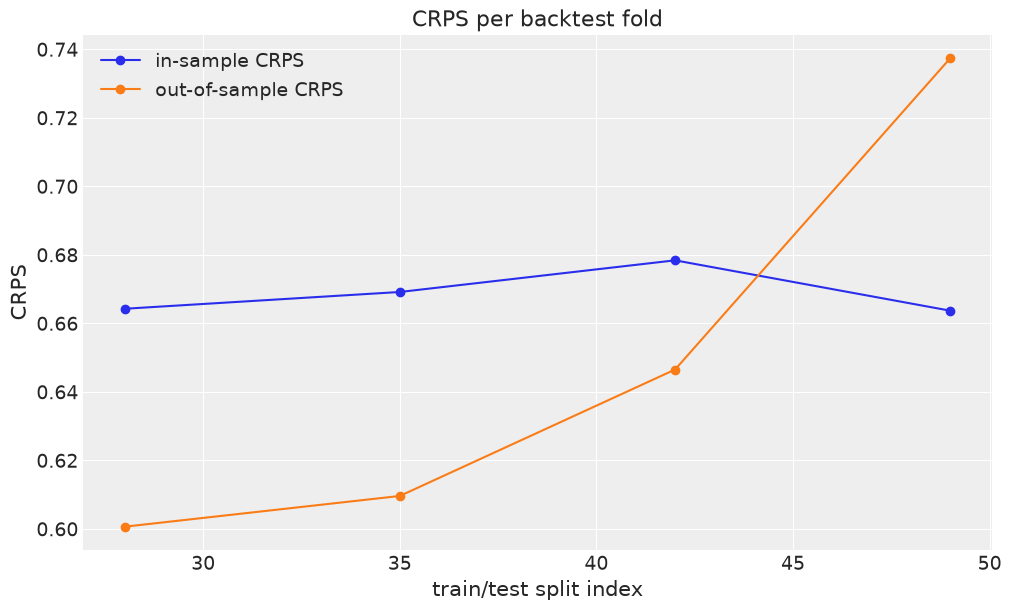

In [12]:
fig, ax = plt.subplots()
ax.plot(summary["t1"], summary["train_crps"], "o-", color="C0", label="in-sample CRPS")
ax.plot(summary["t1"], summary["crps"], "o-", color="C1", label="out-of-sample CRPS")
ax.legend()
ax.set(xlabel="train/test split index", ylabel="CRPS", title="CRPS per backtest fold")
plt.show()


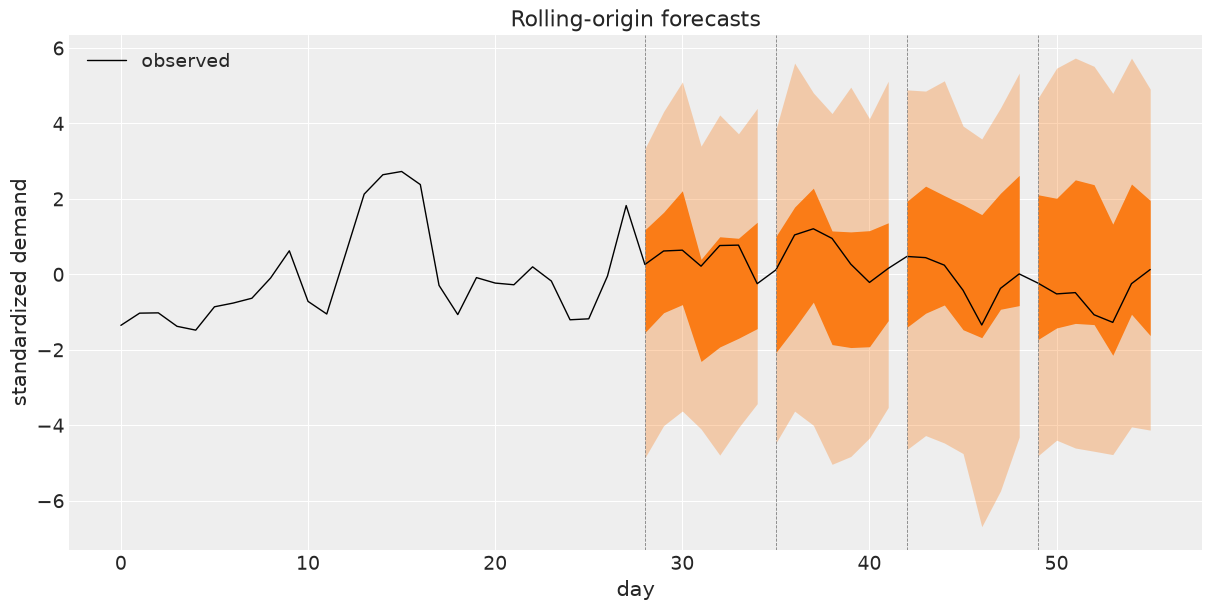

In [13]:
pc = None
for result in results:
    if result.prediction is None:
        continue
    truth = y.isel({TIME_DIM: slice(result.t1, result.t2)}).rename({TIME_DIM: FUTURE_DIM})
    fold_idata = lm_idata_from_forecast(
        result.prediction,
        truth,
        x_name="day",
        x_values=np.arange(result.t1, result.t2),
    )
    if pc is None:
        pc = az.plot_lm(
            fold_idata,
            y="obs",
            x="day",
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
            figure_kwargs={"figsize": (12, 6)},
        )
    else:
        az.plot_lm(
            fold_idata,
            y="obs",
            x="day",
            plot_collection=pc,
            ci_kind="hdi",
            ci_prob=(0.5, 0.94),
            smooth=False,
            visuals={"ci_band": {"color": "C1"}, "observed_scatter": False, "pe_line": False},
        )

if pc is None:
    msg = "no folds were plotted"
    raise ValueError(msg)
ax = pc.viz["figure"].item().axes[0]
ax.plot(np.arange(duration), y.values, color="black", lw=1, label="observed")
for result in results:
    ax.axvline(result.t1, color="gray", ls="--", lw=0.6)
ax.legend(loc="upper left")
ax.set(title="Rolling-origin forecasts", xlabel="day", ylabel="standardized demand")
plt.show()


## Functional API


In [14]:
def local_level_seasonal(h: Horizon, covariates: xr.DataArray) -> None:
    """Functional twin of ``LocalLevelSeasonal.model``."""
    bias = pm.Normal("bias", 0.0, 1.0)
    weight = pm.Normal("weight", 0.0, 0.3, dims="covariate")
    drift_scale = pm.HalfNormal("drift_scale", 0.02)
    sigma = pm.HalfNormal("sigma", 0.5)
    nu_minus_two = pm.Exponential("nu_minus_two", 1 / 10)
    nu = pm.Deterministic("nu", nu_minus_two + 2.0)

    drift = time_series(
        h,
        "drift",
        lambda name, dims: pm.Normal(name, 0.0, drift_scale, dims=dims),
    )
    level = pt.cumsum(drift)
    regression = pt.dot(covariates.values, weight)

    predict(
        h,
        lambda name, mu, dims, observed: pm.StudentT(
            name,
            nu=nu,
            mu=mu,
            sigma=sigma,
            dims=dims,
            observed=observed,
        ),
        bias + level + regression,
    )


oop_names = list(build_model(LocalLevelSeasonal(), y_train, covariates_train).named_vars)
functional_names = list(build_model(local_level_seasonal, y_train, covariates_train).named_vars)
print("same named variables:", oop_names == functional_names)
print(functional_names)


same named variables: True
['bias', 'weight', 'drift_scale', 'sigma', 'nu_minus_two', 'nu', 'drift', 'obs']


## References

- Upstream NumPyro notebook: https://github.com/juanitorduz/numpyro_forecast/blob/main/docs/examples/forecasting_univariate.ipynb
- Juan Orduz, Univariate time series forecasting with NumPyro: https://juanitorduz.github.io/numpyro_forecasting-univariate/
